# A

In [1]:
# import torch
# import torch.nn as nn
# import pandas as pd
# import numpy as np
# from scipy.signal import savgol_filter
# import os

# DIC_FILE = 'DIC_2D_Data.csv'
# UTM_FILE = 'Specimen_RawData_1.csv'
# CHECKPOINT_FILE = 'Lattice_DigitalTwin_Weights.pth'

# CROSS_SECTIONAL_AREA = 20.0 * 4.0 
# POISSONS_RATIO = 0.3
# DIC_FRAME_RATE = 10.0 

# EPOCHS = 2000
# LR = 1e-3
# LAMBDA_DATA = 1.0
# LAMBDA_PDE = 1.0
# LAMBDA_BC_RATE = 1e-1

# def process_synchronized_tensors(dic_path, utm_path):
#     utm_df = pd.read_csv(utm_path, skiprows=[1])
#     utm_df = utm_df.apply(pd.to_numeric, errors='coerce').dropna()
    
#     utm_time = utm_df['Time'].values
#     utm_load = utm_df['Load'].values
#     filtered_load = savgol_filter(utm_load, window_length=51, polyorder=3)
    
#     dt = np.mean(np.diff(utm_time))
#     load_dot = np.gradient(filtered_load, dt)
#     load_ddot = np.gradient(load_dot, dt)
    
#     dic_df = pd.read_csv(dic_path)
#     dic_df['Absolute_Time'] = dic_df['img_no'] / DIC_FRAME_RATE
    
#     dic_time = dic_df['Absolute_Time'].values
#     sync_load_dot = np.interp(dic_time, utm_time, load_dot)
#     sync_load_ddot = np.interp(dic_time, utm_time, load_ddot)
    
#     t_tensor = torch.tensor(dic_time, dtype=torch.float32).view(-1, 1).requires_grad_(True)
#     x_tensor = torch.tensor(dic_df['x_pic_AVG'].values, dtype=torch.float32).view(-1, 1).requires_grad_(True)
#     y_tensor = torch.tensor(dic_df['y_pic_AVG'].values, dtype=torch.float32).view(-1, 1).requires_grad_(True)
    
#     u_emp = torch.tensor(dic_df['u_AVG'].values, dtype=torch.float32).view(-1, 1)
#     v_emp = torch.tensor(dic_df['v_AVG'].values, dtype=torch.float32).view(-1, 1)
    
#     p_dot_tensor = torch.tensor(sync_load_dot, dtype=torch.float32).view(-1, 1)
#     p_ddot_tensor = torch.tensor(sync_load_ddot, dtype=torch.float32).view(-1, 1)

#     return x_tensor, y_tensor, t_tensor, u_emp, v_emp, p_dot_tensor, p_ddot_tensor

# class FourierFeatureEncoding(nn.Module):
#     def __init__(self, input_dim, mapping_size, scale=1.0):
#         super(FourierFeatureEncoding, self).__init__()
#         self.B = nn.Parameter(torch.randn(input_dim, mapping_size) * scale, requires_grad=False)

#     def forward(self, x):
#         x_proj = 2.0 * np.pi * x @ self.B
#         return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

# class OptimizedBifurcatedPINN(nn.Module):
#     def __init__(self, fourier_features=64):
#         super(OptimizedBifurcatedPINN, self).__init__()
#         self.encoder = FourierFeatureEncoding(input_dim=3, mapping_size=fourier_features)
        
#         self.shared_trunk = nn.Sequential(
#             nn.Linear(fourier_features * 2, 256),
#             nn.SiLU(),
#             nn.Linear(256, 128),
#             nn.SiLU()
#         )
        
#         self.kinematic_head = nn.Sequential(
#             nn.Linear(128, 64),
#             nn.SiLU(),
#             nn.Linear(64, 2)
#         )
        
#         self.constitutive_head = nn.Sequential(
#             nn.Linear(128, 64),
#             nn.SiLU(),
#             nn.Linear(64, 2)
#         )

#     def forward(self, x, y, t):
#         inputs = torch.cat([x, y, t], dim=1)
#         encoded = self.encoder(inputs)
#         latent = self.shared_trunk(encoded)
        
#         kinematics = self.kinematic_head(latent)
#         u = kinematics[:, 0:1]
#         v = kinematics[:, 1:2]
        
#         constitutive = self.constitutive_head(latent)
#         E = torch.nn.functional.softplus(constitutive[:, 0:1]) + 1.0
#         G = torch.nn.functional.softplus(constitutive[:, 1:2]) + 1.0
        
#         return u, v, E, G

# def compute_total_loss(model, x, y, t, u_emp, v_emp, p_dot_emp, p_ddot_emp):
#     u_pred, v_pred, E_pred, G_pred = model(x, y, t)
    
#     loss_data = torch.mean((u_pred - u_emp)**2 + (v_pred - v_emp)**2)
    
#     u_x = torch.autograd.grad(u_pred, x, torch.ones_like(u_pred), create_graph=True)[0]
#     u_y = torch.autograd.grad(u_pred, y, torch.ones_like(u_pred), create_graph=True)[0]
#     v_x = torch.autograd.grad(v_pred, x, torch.ones_like(v_pred), create_graph=True)[0]
#     v_y = torch.autograd.grad(v_pred, y, torch.ones_like(v_pred), create_graph=True)[0]
    
#     eps_xx = u_x
#     eps_yy = v_y
#     gamma_xy = u_y + v_x
    
#     stiffness_factor = E_pred / (1 - POISSONS_RATIO**2)
#     sigma_xx = stiffness_factor * (eps_xx + POISSONS_RATIO * eps_yy)
#     sigma_yy = stiffness_factor * (eps_yy + POISSONS_RATIO * eps_xx)
#     tau_xy = G_pred * gamma_xy
    
#     sigma_xx_x = torch.autograd.grad(sigma_xx, x, torch.ones_like(sigma_xx), create_graph=True)[0]
#     tau_xy_y = torch.autograd.grad(tau_xy, y, torch.ones_like(tau_xy), create_graph=True)[0]
    
#     tau_xy_x = torch.autograd.grad(tau_xy, x, torch.ones_like(tau_xy), create_graph=True)[0]
#     sigma_yy_y = torch.autograd.grad(sigma_yy, y, torch.ones_like(sigma_yy), create_graph=True)[0]
    
#     res_x = sigma_xx_x + tau_xy_y
#     res_y = tau_xy_x + sigma_yy_y
#     loss_pde = torch.mean(res_x**2 + res_y**2)
    
#     force_computed = sigma_yy * CROSS_SECTIONAL_AREA
    
#     force_dot = torch.autograd.grad(force_computed, t)#, torch.ones_like(force_computed), create_graph=True)[0]
#     force_ddot = torch.autograd.grad(force_dot, t)#, torch.ones_like(force_dot), create_graph=True)[0]
    
#     loss_bc_rate = torch.mean((force_dot - p_dot_emp)**2)
#     loss_bc_accel = torch.mean((force_ddot - p_ddot_emp)**2)
    
#     loss_boundary = loss_bc_rate + loss_bc_accel
    
#     total_loss = (LAMBDA_DATA * loss_data) + \
#                  (LAMBDA_PDE * loss_pde) + \
#                  (LAMBDA_BC_RATE * loss_boundary)
                 
#     return total_loss, loss_data, loss_pde, loss_boundary

# if __name__ == "__main__":
#     if os.path.exists(DIC_FILE) and os.path.exists(UTM_FILE):
#         X, Y, T, U_exp, V_exp, P_dot, P_ddot = process_synchronized_tensors(DIC_FILE, UTM_FILE)
        
#         model = OptimizedBifurcatedPINN()
#         optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        
#         start_epoch = 0
        
#         if os.path.exists(CHECKPOINT_FILE):
#             checkpoint = torch.load(CHECKPOINT_FILE)
            
#             if 'model_state_dict' in checkpoint:
#                 model.load_state_dict(checkpoint['model_state_dict'])
#                 optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
#                 start_epoch = checkpoint['epoch'] + 1
#                 print(f"Resuming parameter optimization. Bypassing to epoch {start_epoch}.")
#             else:
#                 model.load_state_dict(checkpoint)
#                 start_epoch = 0
#                 print("Legacy weight artifact detected. Ingesting spatial parameters, initializing momentum tensors at epoch 0.")
#         else:
#             print("No baseline state artifact detected. Initializing optimization tensor from epoch 0.")
            
#         for epoch in range(start_epoch, EPOCHS):
#             optimizer.zero_grad()
            
#             loss, l_data, l_pde, l_bc = compute_total_loss(model, X, Y, T, U_exp, V_exp, P_dot, P_ddot)
            
#             loss.backward()
#             optimizer.step()
            
#             if epoch % 100 == 0 or epoch == EPOCHS - 1:
#                 print(f"Epoch [{epoch}/{EPOCHS}] | Total Loss: {loss.item():.4e} | "
#                       f"Data: {l_data.item():.4e} | PDE: {l_pde.item():.4e} | BC Rate: {l_bc.item():.4e}")
                
#                 torch.save({
#                     'epoch': epoch,
#                     'model_state_dict': model.state_dict(),
#                     'optimizer_state_dict': optimizer.state_dict(),
#                     'loss': loss.item()
#                 }, CHECKPOINT_FILE)
                
#         print("Optimization Converged. Persistent weights updated.")
#     else:
#         print(f"System Error: Required I/O matrices {DIC_FILE} or {UTM_FILE} absent from directory.")

# B

In [10]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter
import os
from torch.utils.data import TensorDataset, DataLoader
torch.set_float32_matmul_precision('high')

DIC_FILE = 'DIC_2D_Data.csv'
UTM_FILE = 'Specimen_RawData_1.csv'
CHECKPOINT_FILE = 'Lattice_DigitalTwin_Weights_sim.pth'

CROSS_SECTIONAL_AREA = 20.0 * 4.0 
POISSONS_RATIO = 0.3
MATERIAL_DENSITY = 1.2e-9 
DIC_FRAME_RATE = 10.0 
# 70 GPa converted to MPa to match the mm/N unit system
E_REFERENCE = 70e3

# Optimization Hyperparameters
EPOCHS = 2000
LR = 1e-3
BATCH_SIZE = 8192
LAMBDA_DATA = 1.0
LAMBDA_PDE = 1e-7          # Scaled down to match dimensionless O(1) Data Loss
LAMBDA_BC_DIRIC = 1.0 
LAMBDA_BC_NEUM = 1e-4      # Scaled for MPa traction variance
LAMBDA_BC_FORCE = 1e-5     # Scaled for Force temporal derivative variance

def smooth_displacement_field(df: pd.DataFrame, cols=('u_AVG', 'v_AVG'), window: int = 11, polyorder: int = 3) -> pd.DataFrame:
    df_out = df.copy()
    for frame_id, group in df_out.groupby('img_no'):
        idx = group.index
        for col in cols:
            vals = group[col].values
            win = min(window, len(vals) if len(vals) % 2 == 1 else len(vals) - 1)
            win = max(win, polyorder + 2 if (polyorder + 2) % 2 == 1 else polyorder + 3)
            if len(vals) >= win:
                df_out.loc[idx, col] = savgol_filter(vals, window_length=win, polyorder=polyorder)
    return df_out

class Normalizer:
    def __init__(self):
        self.mean: dict[str, float] = {}
        self.std:  dict[str, float] = {}

    def fit_transform(self, tensor: torch.Tensor, name: str) -> torch.Tensor:
        m = tensor.mean().item()
        s = tensor.std().item()
        s = s if s > 1e-8 else 1.0
        self.mean[name] = m
        self.std[name]  = s
        return (tensor - m) / s

    def inverse(self, tensor: torch.Tensor, name: str) -> torch.Tensor:
        return tensor * self.std[name] + self.mean[name]

def process_synchronized_tensors(dic_path: str, utm_path: str, subsample_ratio: float = 0.2):
    utm_df = pd.read_csv(utm_path, skiprows=[1])
    utm_df = utm_df.apply(pd.to_numeric, errors='coerce').dropna()

    utm_time = utm_df['Time'].values
    utm_load = utm_df['Load'].values
    filt_load = savgol_filter(utm_load, window_length=51, polyorder=3)

    dt = np.mean(np.diff(utm_time))
    load_dot = np.gradient(filt_load, dt)
    load_ddot = np.gradient(load_dot, dt)

    dic_df = pd.read_csv(dic_path)
    dic_df['Absolute_Time'] = dic_df['img_no'] / DIC_FRAME_RATE

    # Execute spatial smoothing prior to decimation to preserve signal continuity
    dic_df = smooth_displacement_field(dic_df)

    # --- Stochastic Spatial Subsampling ---
    if subsample_ratio < 1.0:
        original_size = len(dic_df)
        dic_df = dic_df.sample(frac=subsample_ratio, random_state=42).reset_index(drop=True)
        print(f"Subsampling active: Reduced tensor dimension from {original_size} to {len(dic_df)} nodes.")

    dic_time = dic_df['Absolute_Time'].values
    sync_load = np.interp(dic_time, utm_time, filt_load)
    sync_load_dot = np.interp(dic_time, utm_time, load_dot)
    sync_load_ddot = np.interp(dic_time, utm_time, load_ddot)

    t_raw = torch.tensor(dic_time, dtype=torch.float32).view(-1, 1)
    x_raw = torch.tensor(dic_df['x_pic_AVG'].values, dtype=torch.float32).view(-1, 1)
    y_raw = torch.tensor(dic_df['y_pic_AVG'].values, dtype=torch.float32).view(-1, 1)
    u_raw = torch.tensor(dic_df['u_AVG'].values, dtype=torch.float32).view(-1, 1)
    v_raw = torch.tensor(dic_df['v_AVG'].values, dtype=torch.float32).view(-1, 1)

    p_tensor = torch.tensor(sync_load, dtype=torch.float32).view(-1, 1)
    p_dot_tensor = torch.tensor(sync_load_dot, dtype=torch.float32).view(-1, 1)
    p_ddot_tensor = torch.tensor(sync_load_ddot, dtype=torch.float32).view(-1, 1)

    norm = Normalizer()
    x_n = norm.fit_transform(x_raw, 'x')
    y_n = norm.fit_transform(y_raw, 'y')
    t_n = norm.fit_transform(t_raw, 't')
    u_n = norm.fit_transform(u_raw, 'u')
    v_n = norm.fit_transform(v_raw, 'v')

    y_min_norm = ((y_raw.min().item() - norm.mean['y']) / norm.std['y'])
    y_max_norm = ((y_raw.max().item() - norm.mean['y']) / norm.std['y'])
    eps = 0.05 

    bottom_mask = (y_n < y_min_norm + eps).squeeze()
    top_mask = (y_n > y_max_norm - eps).squeeze()

    return x_n, y_n, t_n, u_n, v_n, p_tensor, p_dot_tensor, p_ddot_tensor, bottom_mask, top_mask, norm

In [ ]:
E_Reference = 70e3  # MPa, equivalent to 70 GPa in the mm/N unit system
class FourierFeatureEncoding(nn.Module):
    def __init__(self, input_dim: int, mapping_size: int, scale: float = 1.0):
        super().__init__()
        B = torch.randn(input_dim, mapping_size) * scale
        self.register_buffer('B', B)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x_proj = 2.0 * np.pi * x @ self.B
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class OptimizedBifurcatedPINN(nn.Module):
    def __init__(self, fourier_features: int = 64):
        super().__init__()
        self.encoder = FourierFeatureEncoding(input_dim=3, mapping_size=fourier_features)

        self.shared_trunk = nn.Sequential(
            nn.Linear(fourier_features * 2, 256), nn.SiLU(),
            nn.Linear(256, 128), nn.SiLU(),
        )

        self.kinematic_head = nn.Sequential(
            nn.Linear(128, 64), nn.SiLU(),
            nn.Linear(64, 2),
        )

        self.constitutive_head = nn.Sequential(
            nn.Linear(128, 64), nn.SiLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x, y, t):
        inputs = torch.cat([x, y, t], dim=1)
        encoded = self.encoder(inputs)
        latent = self.shared_trunk(encoded)

        kinematics = self.kinematic_head(latent)
        u = kinematics[:, 0:1]
        v = kinematics[:, 1:2]

        E_raw = self.constitutive_head(latent)
        E = (torch.nn.functional.softplus(E_raw) + 1.0) * E_Reference
        G = E / (2.0 * (1.0 + POISSONS_RATIO))

        return u, v, E, G

def compute_total_loss(model, x, y, t, u_emp, v_emp, p_emp, p_dot_emp, p_ddot_emp, bottom_mask, top_mask, norm: Normalizer):
    u_pred, v_pred, E_pred, G_pred = model(x, y, t)

    # 1. Empirical Loss (Evaluated in Normalized Domain for stability)
    loss_data = torch.mean((u_pred - u_emp)**2 + (v_pred - v_emp)**2)

    def grad(out_tensor, inp_tensor):
        g = torch.autograd.grad(out_tensor, inp_tensor, torch.ones_like(out_tensor), create_graph=True, allow_unused=True)[0]
        return g if g is not None else torch.zeros_like(inp_tensor)

    # --- DIMENSIONAL RESTORATION PROTOCOL ---
    # Retrieve Z-Score standard deviations
    std_x = norm.std['x']
    std_y = norm.std['y']
    std_t = norm.std['t']
    std_u = norm.std['u']
    std_v = norm.std['v']

    # 2. Kinematic Gradients (Chain Rule Mapping to Physical Strains)
    u_x_norm = grad(u_pred, x)
    u_y_norm = grad(u_pred, y)
    v_x_norm = grad(v_pred, x)
    v_y_norm = grad(v_pred, y)

    eps_xx = u_x_norm * (std_u / std_x)
    eps_yy = v_y_norm * (std_v / std_y)
    gamma_xy = (u_y_norm * (std_u / std_y)) + (v_x_norm * (std_v / std_x))

    # 3. Constitutive Mapping (Physical Space, MPa)
    factor = E_pred / (1.0 - POISSONS_RATIO**2)
    sigma_xx = factor * (eps_xx + POISSONS_RATIO * eps_yy)
    sigma_yy = factor * (eps_yy + POISSONS_RATIO * eps_xx)
    tau_xy = G_pred * gamma_xy

    # 4. Stress Gradients (Mapping to Physical Space, MPa/mm)
    sigma_xx_x = grad(sigma_xx, x) / std_x
    tau_xy_y   = grad(tau_xy, y) / std_y
    tau_xy_x   = grad(tau_xy, x) / std_x
    sigma_yy_y = grad(sigma_yy, y) / std_y

    # 5. Kinematic Accelerations (Mapping to Physical Space, mm/s^2)
    u_t_norm = grad(u_pred, t)
    u_tt_norm = grad(u_t_norm, t)
    v_t_norm = grad(v_pred, t)
    v_tt_norm = grad(v_t_norm, t)

    u_tt_phys = u_tt_norm * (std_u / (std_t**2))
    v_tt_phys = v_tt_norm * (std_v / (std_t**2))

    inertia_x = MATERIAL_DENSITY * u_tt_phys
    inertia_y = MATERIAL_DENSITY * v_tt_phys

    # 6. PDE Equilibrium Residuals
    res_x = (sigma_xx_x + tau_xy_y) - inertia_x
    res_y = (tau_xy_x + sigma_yy_y) - inertia_y
    loss_pde = torch.mean(res_x**2 + res_y**2)

    # 7. Differential Force Boundary Formulation
    sigma_yy_t = grad(sigma_yy, t) / std_t
    sigma_yy_tt = grad(sigma_yy_t, t) / std_t

    force_dot_local = sigma_yy_t * CROSS_SECTIONAL_AREA
    force_ddot_local = sigma_yy_tt * CROSS_SECTIONAL_AREA

    loss_bc_rate = torch.mean((force_dot_local - p_dot_emp)**2)
    loss_bc_accel = torch.mean((force_ddot_local - p_ddot_emp)**2)
    loss_force_bc = loss_bc_rate + loss_bc_accel

    # 8. Spatial Boundary Constraints
    if bottom_mask.any():
        u_bottom_phys = (u_pred[bottom_mask] * std_u) + norm.mean['u']
        v_bottom_phys = (v_pred[bottom_mask] * std_v) + norm.mean['v']
        loss_dirichlet = torch.mean(u_bottom_phys**2 + v_bottom_phys**2)
    else:
        loss_dirichlet = torch.tensor(0.0, device=x.device)

    if top_mask.any():
        sigma_yy_top = sigma_yy[top_mask]
        traction_target = (p_emp[top_mask] / (CROSS_SECTIONAL_AREA + 1e-12))
        loss_neumann = torch.mean((sigma_yy_top - traction_target)**2)
    else:
        loss_neumann = torch.tensor(0.0, device=x.device)

    # Objective Aggregation
    total_loss = (LAMBDA_DATA * loss_data +
                  LAMBDA_PDE * loss_pde +
                  LAMBDA_BC_FORCE * loss_force_bc +
                  LAMBDA_BC_DIRIC * loss_dirichlet +
                  LAMBDA_BC_NEUM * loss_neumann)

    return total_loss, loss_data, loss_pde, loss_force_bc, loss_dirichlet, loss_neumann

if __name__ == "__main__":
    # --- 1. GPU CHECK & ASSIGNMENT ---
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on Device: {device.type.upper()}")
    
    if not (os.path.exists(DIC_FILE) and os.path.exists(UTM_FILE)):
        print(f"ERROR: Required data files '{DIC_FILE}' or '{UTM_FILE}' not found.")
    else:
        X, Y, T, U_exp, V_exp, P_emp, P_dot, P_ddot, bottom_mask, top_mask, norm = process_synchronized_tensors(DIC_FILE, UTM_FILE)

        dataset = TensorDataset(X, Y, T, U_exp, V_exp, P_emp, P_dot, P_ddot, bottom_mask, top_mask)
        dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

        # --- 2. MODEL MIGRATION TO GPU ---
        model = OptimizedBifurcatedPINN().to(device)
        # model = torch.compile(model, mode="reduce-overhead")
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        start_epoch = 0

        if os.path.exists(CHECKPOINT_FILE):
            checkpoint = torch.load(CHECKPOINT_FILE, map_location=device)
            if 'model_state_dict' in checkpoint:
                model.load_state_dict(checkpoint['model_state_dict'])
                optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
                start_epoch = checkpoint['epoch'] + 1
                print(f"Resuming from epoch {start_epoch}.")
            else:
                model.load_state_dict(checkpoint)
                print("Legacy checkpoint loaded; restarting epoch counter.")
        else:
            print("No checkpoint found. Initialising from scratch.")
        
        # model = torch.compile(model, mode="reduce-overhead")

        # # Initialize optimizer on the compiled parameters
        # optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        
        # # Load optimizer state if resuming
        # if checkpoint and 'optimizer_state_dict' in checkpoint:
        #     optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

        for epoch in range(start_epoch, EPOCHS):
            model.train()
            epoch_loss = 0.0
            epoch_data = 0.0
            epoch_pde = 0.0

            for batch_idx, batch_data in enumerate(dataloader):
                # --- 3. BATCH MIGRATION TO GPU ---
                x_b, y_b, t_b, u_b, v_b, p_b, p_dot_b, p_ddot_b, b_mask, t_mask = [
                    tensor.to(device) for tensor in batch_data
                ]

                x_b.requires_grad_(True)
                y_b.requires_grad_(True)
                t_b.requires_grad_(True)

                optimizer.zero_grad()

                loss, l_data, l_pde, l_force, l_diric, l_neum = compute_total_loss(
                    model, x_b, y_b, t_b, u_b, v_b, p_b, p_dot_b, p_ddot_b, b_mask, t_mask, norm
                )

                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()
                epoch_data += l_data.item()
                epoch_pde += l_pde.item()

            num_batches = len(dataloader)
            avg_loss = epoch_loss / num_batches
            avg_data = epoch_data / num_batches
            avg_pde = epoch_pde / num_batches

            if epoch % 10 == 0 or epoch == EPOCHS - 1:
                print(
                    f"Epoch [{epoch:>4}/{EPOCHS}] | "
                    f"Avg Total: {avg_loss:.4e} | "
                    f"Avg Data: {avg_data:.4e} | "
                    f"Avg PDE: {avg_pde:.4e}"
                    f"Avg Force BC: {l_force.item():.4e} | "
                    f"Avg Dirichlet BC: {l_diric.item():.4e} | "
                    f"Avg Neumann BC: {l_neum.item():.4e} | "
                )
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss': avg_loss,
                    'normalizer_mean': norm.mean,
                    'normalizer_std': norm.std,
                }, CHECKPOINT_FILE)

        print("Training complete. Checkpoint saved.")

# C

In [41]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter
import os
from torch.utils.data import TensorDataset, DataLoader
torch.set_float32_matmul_precision('high')

DIC_FILE = 'DIC_2D_Data.csv'
UTM_FILE = 'Specimen_RawData_1.csv'
CHECKPOINT_FILE = 'Weights_2.pth'

CROSS_SECTIONAL_AREA = 20.0 * 4.0 
POISSONS_RATIO = 0.3
MATERIAL_DENSITY = 2.7e-9 
DIC_FRAME_RATE = 10.0 
E_REFERENCE = 700

# Optimization Hyperparameters
EPOCHS = 2000
LR_THETA = 1e-3
LR_LAMBDA = 1e-4       # Learning rate for the Lagrangian Multipliers
BATCH_SIZE = 8192
LAMBDA_DATA = 1.0      # Anchor primal loss (static)

def smooth_displacement_field(df: pd.DataFrame, cols=('u_AVG', 'v_AVG'), window: int = 11, polyorder: int = 3) -> pd.DataFrame:
    df_out = df.copy()
    for frame_id, group in df_out.groupby('img_no'):
        idx = group.index
        for col in cols:
            vals = group[col].values
            win = min(window, len(vals) if len(vals) % 2 == 1 else len(vals) - 1)
            win = max(win, polyorder + 2 if (polyorder + 2) % 2 == 1 else polyorder + 3)
            if len(vals) >= win:
                df_out.loc[idx, col] = savgol_filter(vals, window_length=win, polyorder=polyorder)
    return df_out

class Normalizer:
    def __init__(self):
        self.mean: dict[str, float] = {}
        self.std:  dict[str, float] = {}

    def fit_transform(self, tensor: torch.Tensor, name: str) -> torch.Tensor:
        m = tensor.mean().item()
        s = tensor.std().item()
        s = s if s > 1e-8 else 1.0
        self.mean[name] = m
        self.std[name]  = s
        return (tensor - m) / s

    def inverse(self, tensor: torch.Tensor, name: str) -> torch.Tensor:
        return tensor * self.std[name] + self.mean[name]

def process_synchronized_tensors(dic_path: str, utm_path: str, checkpoint_norm: Normalizer = None, subsample_ratio: float = 0.2):
    utm_df = pd.read_csv(utm_path, skiprows=[1])
    utm_df = utm_df.apply(pd.to_numeric, errors='coerce').dropna()

    utm_time = utm_df['Time'].values
    utm_load = utm_df['Load'].values * 1000
    filt_load = savgol_filter(utm_load, window_length=51, polyorder=3)

    dt = np.mean(np.diff(utm_time))
    load_dot = np.gradient(filt_load, dt)
    load_ddot = np.gradient(load_dot, dt)

    dic_df = pd.read_csv(dic_path)
    dic_df['Absolute_Time'] = dic_df['img_no'] / DIC_FRAME_RATE

    # Execute spatial smoothing prior to decimation to preserve signal continuity
    dic_df = smooth_displacement_field(dic_df)

    # --- Stochastic Spatial Subsampling ---
    if subsample_ratio < 1.0:
        original_size = len(dic_df)
        dic_df = dic_df.sample(frac=subsample_ratio, random_state=42).reset_index(drop=True)
        print(f"Subsampling active: Reduced tensor dimension from {original_size} to {len(dic_df)} nodes.")

    dic_time = dic_df['Absolute_Time'].values
    sync_load = np.interp(dic_time, utm_time, filt_load)
    sync_load_dot = np.interp(dic_time, utm_time, load_dot)
    sync_load_ddot = np.interp(dic_time, utm_time, load_ddot)

    t_raw = torch.tensor(dic_time, dtype=torch.float32).view(-1, 1)
    x_raw = torch.tensor(dic_df['x_pic_AVG'].values, dtype=torch.float32).view(-1, 1)
    y_raw = torch.tensor(dic_df['y_pic_AVG'].values, dtype=torch.float32).view(-1, 1)
    u_raw = torch.tensor(dic_df['u_AVG'].values, dtype=torch.float32).view(-1, 1)
    v_raw = torch.tensor(dic_df['v_AVG'].values, dtype=torch.float32).view(-1, 1)

    p_tensor = torch.tensor(sync_load, dtype=torch.float32).view(-1, 1)
    p_dot_tensor = torch.tensor(sync_load_dot, dtype=torch.float32).view(-1, 1)
    p_ddot_tensor = torch.tensor(sync_load_ddot, dtype=torch.float32).view(-1, 1)

    norm = Normalizer()
    # x_n = norm.fit_transform(x_raw, 'x')
    # y_n = norm.fit_transform(y_raw, 'y')
    # t_n = norm.fit_transform(t_raw, 't')
    # u_n = norm.fit_transform(u_raw, 'u')
    # v_n = norm.fit_transform(v_raw, 'v')
    if checkpoint_norm is not None:
        x_n = (x_raw - checkpoint_norm.mean['x']) / checkpoint_norm.std['x']
        y_n = (y_raw - checkpoint_norm.mean['y']) / checkpoint_norm.std['y']
        t_n = (t_raw - checkpoint_norm.mean['t']) / checkpoint_norm.std['t']
        u_n = (u_raw - checkpoint_norm.mean['u']) / checkpoint_norm.std['u']
        v_n = (v_raw - checkpoint_norm.mean['v']) / checkpoint_norm.std['v']
        y_min_norm = ((y_raw.min().item() - checkpoint_norm.mean['y']) / checkpoint_norm.std['y'])
        y_max_norm = ((y_raw.max().item() - checkpoint_norm.mean['y']) / checkpoint_norm.std['y'])
    else:
        x_n = norm.fit_transform(x_raw, 'x')
        y_n = norm.fit_transform(y_raw, 'y')
        t_n = norm.fit_transform(t_raw, 't')
        u_n = norm.fit_transform(u_raw, 'u')
        v_n = norm.fit_transform(v_raw, 'v')
        y_min_norm = ((y_raw.min().item() - norm.mean['y']) / norm.std['y'])
        y_max_norm = ((y_raw.max().item() - norm.mean['y']) / norm.std['y'])
    eps = 0.05 

    bottom_mask = (y_n < y_min_norm + eps).squeeze()
    top_mask = (y_n > y_max_norm - eps).squeeze()

    return x_n, y_n, t_n, u_n, v_n, p_tensor, p_dot_tensor, p_ddot_tensor, bottom_mask, top_mask, norm

class FourierFeatureEncoding(nn.Module):
    def __init__(self, input_dim: int, mapping_size: int, scale: float = 1.0):
        super().__init__()
        B = torch.randn(input_dim, mapping_size) * scale
        self.register_buffer('B', B)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x_proj = 2.0 * np.pi * x @ self.B
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class OptimizedBifurcatedPINN(nn.Module):
    def __init__(self, fourier_features: int = 64):
        super().__init__()
        # Separate encoders: kinematics uses higher freq, material uses lower
        self.encoder_kin = FourierFeatureEncoding(3, fourier_features, scale=1.0)
        self.encoder_mat = FourierFeatureEncoding(3, fourier_features // 2, scale=0.25)

        feat_kin = fourier_features * 2
        feat_mat = fourier_features  # half features, so still *2 from sin/cos

        # Kinematic branch (unchanged — it's working)
        self.kin_trunk = nn.Sequential(
            nn.Linear(feat_kin, 256), nn.SiLU(),
            nn.Linear(256, 128), nn.SiLU(),
        )
        self.kinematic_head = nn.Sequential(
            nn.Linear(128, 64), nn.SiLU(),
            nn.Linear(64, 2),
        )

        # Dedicated material branch — fully separated
        self.mat_trunk = nn.Sequential(
            nn.Linear(feat_mat, 128), nn.SiLU(),
            nn.Linear(128, 64), nn.SiLU(),
            nn.Linear(64, 32), nn.SiLU(),
        )
        self.constitutive_head = nn.Sequential(
            nn.Linear(32, 16), nn.SiLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x, y, t):
        coords = torch.cat([x, y, t], dim=1)

        # Kinematic path
        kin_enc = self.encoder_kin(coords)
        kin_lat = self.kin_trunk(kin_enc)
        kinematics = self.kinematic_head(kin_lat)
        u = kinematics[:, 0:1]
        v = kinematics[:, 1:2]

        # Material path — use only spatial coords (x, y), not t
        # E should not vary in time for a solid specimen
        xy_only = torch.cat([x, y, torch.zeros_like(t)], dim=1)
        mat_enc = self.encoder_mat(xy_only)
        mat_lat = self.mat_trunk(mat_enc)
        E_raw = self.constitutive_head(mat_lat)
        E = (torch.nn.functional.softplus(E_raw) + 1.0) * E_REFERENCE
        G = E / (2.0 * (1.0 + POISSONS_RATIO))

        return u, v, E, G

class AdaptiveLagrangianPINN(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.surrogate = base_model
        
        # # Initialized to match previous stable manual tuning equivalents in log space
        # self.log_l_pde = nn.Parameter(torch.tensor([-13.8]))    # ~ 1e-6
        # self.log_l_force = nn.Parameter(torch.tensor([-8.5]))   # ~ 2e-4
        # self.log_l_diric = nn.Parameter(torch.tensor([0.0]))    # ~ 1.0
        # self.log_l_neum = nn.Parameter(torch.tensor([-2.3]))    # ~ 1e-1
        # FIX 3: Re-initialize log multipliers with better priors

        # PDE residuals ~1e4, data ~1.0, so PDE needs λ ~ 1e-4 minimum
        self.log_l_pde = nn.Parameter(torch.tensor([-9.2]))    # ~1e-4
        self.log_l_force = nn.Parameter(torch.tensor([-7.0]))  # ~9e-4
        self.log_l_diric = nn.Parameter(torch.tensor([0.0]))   # ~1.0
        self.log_l_neum = nn.Parameter(torch.tensor([-1.0]))   # ~0.37

    def forward(self, x, y, t):
        return self.surrogate(x, y, t)

    def get_multipliers(self):
        return torch.exp(self.log_l_pde), torch.exp(self.log_l_force), torch.exp(self.log_l_diric), torch.exp(self.log_l_neum)

# --- REFACTORED: Returns Raw Unscaled Residuals ---
def compute_raw_residuals(model, x, y, t, u_emp, v_emp, p_emp, p_dot_emp, p_ddot_emp, bottom_mask, top_mask, norm: Normalizer):
    u_pred, v_pred, E_pred, G_pred = model(x, y, t)

    loss_data = torch.mean((u_pred - u_emp)**2 + (v_pred - v_emp)**2)

    def grad(out_tensor, inp_tensor):
        g = torch.autograd.grad(out_tensor, inp_tensor, torch.ones_like(out_tensor), create_graph=True, allow_unused=True)[0]
        return g if g is not None else torch.zeros_like(inp_tensor)

    # --- DIMENSIONAL RESTORATION PROTOCOL ---
    std_x = norm.std['x']; std_y = norm.std['y']; std_t = norm.std['t']
    std_u = norm.std['u']; std_v = norm.std['v']

    u_x_norm = grad(u_pred, x); u_y_norm = grad(u_pred, y)
    v_x_norm = grad(v_pred, x); v_y_norm = grad(v_pred, y)

    eps_xx = u_x_norm * (std_u / std_x)
    eps_yy = v_y_norm * (std_v / std_y)
    gamma_xy = (u_y_norm * (std_u / std_y)) + (v_x_norm * (std_v / std_x))

    factor = E_pred / (1.0 - POISSONS_RATIO**2)
    sigma_xx = factor * (eps_xx + POISSONS_RATIO * eps_yy)
    sigma_yy = factor * (eps_yy + POISSONS_RATIO * eps_xx)
    tau_xy = G_pred * gamma_xy

    sigma_xx_x = grad(sigma_xx, x) / std_x
    tau_xy_y   = grad(tau_xy, y) / std_y
    tau_xy_x   = grad(tau_xy, x) / std_x
    sigma_yy_y = grad(sigma_yy, y) / std_y

    u_t_norm = grad(u_pred, t)
    u_tt_norm = grad(u_t_norm, t)
    v_t_norm = grad(v_pred, t)
    v_tt_norm = grad(v_t_norm, t)

    u_tt_phys = u_tt_norm * (std_u / (std_t**2))
    v_tt_phys = v_tt_norm * (std_v / (std_t**2))

    inertia_x = MATERIAL_DENSITY * u_tt_phys
    inertia_y = MATERIAL_DENSITY * v_tt_phys

    res_x = (sigma_xx_x + tau_xy_y) - inertia_x
    res_y = (tau_xy_x + sigma_yy_y) - inertia_y
    loss_pde = torch.mean(res_x**2 + res_y**2)

    sigma_yy_t = grad(sigma_yy, t) / std_t
    sigma_yy_tt = grad(sigma_yy_t, t) / std_t

    force_dot_local = sigma_yy_t * CROSS_SECTIONAL_AREA
    force_ddot_local = sigma_yy_tt * CROSS_SECTIONAL_AREA

    loss_bc_rate = torch.mean((force_dot_local - p_dot_emp)**2)
    loss_bc_accel = torch.mean((force_ddot_local - p_ddot_emp)**2)
    loss_force_bc = loss_bc_rate + loss_bc_accel

    if bottom_mask.any():
        u_bottom_phys = (u_pred[bottom_mask] * std_u) + norm.mean['u']
        v_bottom_phys = (v_pred[bottom_mask] * std_v) + norm.mean['v']
        loss_dirichlet = torch.mean(u_bottom_phys**2 + v_bottom_phys**2)
    else:
        loss_dirichlet = torch.tensor(0.0, device=x.device)

    # CORRECT — compute grad over full tensor, then mask
    if top_mask.any():
        sigma_yy_top = sigma_yy[top_mask]
        traction_target = (p_emp[top_mask] / (CROSS_SECTIONAL_AREA + 1e-12))
        loss_neumann = torch.mean((sigma_yy_top - traction_target)**2)
    # if top_mask.any():
    #   sigma_yy_top = sigma_yy[top_mask]
    #   traction_target = (p_emp[top_mask] / (CROSS_SECTIONAL_AREA + 1e-12))
    #   loss_neumann = torch.mean((sigma_yy_top - traction_target)**2)
    else:
        loss_neumann = torch.tensor(0.0, device=x.device)

    # Note: Returning Raw, Unscaled Losses
    return loss_data, loss_pde, loss_force_bc, loss_dirichlet, loss_neumann



In [ ]:
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on Device: {device.type.upper()}")
    
    if not (os.path.exists(DIC_FILE) and os.path.exists(UTM_FILE)):
        print(f"ERROR: Required data files '{DIC_FILE}' or '{UTM_FILE}' not found.")
    else:
        if os.path.exists(CHECKPOINT_FILE):
            checkpoint = torch.load(CHECKPOINT_FILE, map_location=device)
            saved_norm = Normalizer()
            saved_norm.mean = checkpoint['normalizer_mean']
            saved_norm.std = checkpoint['normalizer_std']
            X, Y, T, U_exp, V_exp, P_emp, P_dot, P_ddot, bottom_mask, top_mask, norm = process_synchronized_tensors(DIC_FILE, UTM_FILE, saved_norm, subsample_ratio=0.01)
        else:
            X, Y, T, U_exp, V_exp, P_emp, P_dot, P_ddot, bottom_mask, top_mask, norm = process_synchronized_tensors(DIC_FILE, UTM_FILE, subsample_ratio=0.01)
        dataset = TensorDataset(X, Y, T, U_exp, V_exp, P_emp, P_dot, P_ddot, bottom_mask, top_mask)
        dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

        raw_state_dict = checkpoint['model_state_dict']
        clean_state_dict = {k.replace('surrogate.', ''): v for k, v in raw_state_dict.items()}
    
        # --- Instantiate Models and Dual Optimizers ---
        base_model = OptimizedBifurcatedPINN()
        model_wrapper = AdaptiveLagrangianPINN(base_model).to(device)

        optimizer_theta = torch.optim.Adam(model_wrapper.surrogate.parameters(), lr=LR_THETA)
        
        # Maximize=True explicitly performs Gradient Ascent for the Lagrangian Multipliers
        optimizer_lambda = torch.optim.Adam([
            model_wrapper.log_l_pde,
            model_wrapper.log_l_force,
            model_wrapper.log_l_diric,
            model_wrapper.log_l_neum
        ], lr=LR_LAMBDA, maximize=True)

        start_epoch = 0

        # --- Robust Legacy Checkpoint Loader ---
        if os.path.exists(CHECKPOINT_FILE):
            checkpoint = torch.load(CHECKPOINT_FILE, map_location=device)
            if 'model_state_dict' in checkpoint:
                # Load weights strictly into surrogate to accommodate wrapper
                try:
                    model_wrapper.load_state_dict(checkpoint['model_state_dict'])
                except RuntimeError:
                    # Fallback for legacy checkpoints that didn't have the wrapper struct
                    model_wrapper.surrogate.load_state_dict(checkpoint['model_state_dict'], strict=False)

                if 'optimizer_theta_state_dict' in checkpoint:
                    optimizer_theta.load_state_dict(checkpoint['optimizer_theta_state_dict'])
                    optimizer_lambda.load_state_dict(checkpoint['optimizer_lambda_state_dict'])
                elif 'optimizer_state_dict' in checkpoint:
                    optimizer_theta.load_state_dict(checkpoint['optimizer_state_dict'])
                
                start_epoch = checkpoint['epoch'] + 1
                print(f"Resuming from epoch {start_epoch}.")
            else:
                model_wrapper.surrogate.load_state_dict(checkpoint, strict=False)
                print("Legacy checkpoint loaded into base surrogate; restarting epoch counter.")
        else:
            print("No checkpoint found. Initialising from scratch.")


        for epoch in range(start_epoch, EPOCHS):
            model_wrapper.train()
            
            epoch_lagrangian = 0.0
            epoch_data = 0.0
            epoch_pde = 0.0

            for batch_idx, batch_data in enumerate(dataloader):
                x_b, y_b, t_b, u_b, v_b, p_b, p_dot_b, p_ddot_b, b_mask, t_mask = [
                    tensor.to(device) for tensor in batch_data
                ]

                x_b.requires_grad_(True)
                y_b.requires_grad_(True)
                t_b.requires_grad_(True)

                optimizer_theta.zero_grad()
                optimizer_lambda.zero_grad()

                # Get Unscaled Residuals
                l_data, l_pde, l_force, l_diric, l_neum = compute_raw_residuals(
                    model_wrapper.surrogate, x_b, y_b, t_b, u_b, v_b, p_b, p_dot_b, p_ddot_b, b_mask, t_mask, norm
                )

                # Get Current Adaptive Lambda Weights
                cur_l_pde, cur_l_force, cur_l_diric, cur_l_neum = model_wrapper.get_multipliers()

                # Formulate the Adaptive Lagrangian Objective
                lagrangian_loss = (LAMBDA_DATA * l_data) + \
                                  (cur_l_pde * l_pde) + \
                                  (cur_l_force * l_force) + \
                                  (cur_l_diric * l_diric) + \
                                  (cur_l_neum * l_neum)

                # Backpropagate through both Neural Weights and Multipliers
                lagrangian_loss.backward()
                
                optimizer_theta.step()
                # optimizer_lambda.step()
                if batch_idx % 5 == 0:
                    optimizer_lambda.step()

                epoch_lagrangian += lagrangian_loss.item()
                epoch_data += l_data.item()
                epoch_pde += l_pde.item()

            num_batches = len(dataloader)
            avg_lagrangian = epoch_lagrangian / num_batches
            avg_data = epoch_data / num_batches
            avg_pde = epoch_pde / num_batches

            if epoch % 10 == 0 or epoch == EPOCHS - 1:
                # Capture Lambdas for logging
                with torch.no_grad():
                    log_pde, log_force, log_diric, log_neum = model_wrapper.get_multipliers()
                    
                print(
                    f"Epoch [{epoch:>4}/{EPOCHS}] | "
                    f"Lagrangian: {avg_lagrangian:.4e} | "
                    f"Data (Raw): {avg_data:.4e} | "
                    f"PDE (Raw): {avg_pde:.4e} || "
                    f"λ_PDE: {log_pde.item():.2e} | "
                    f"λ_Force: {log_force.item():.2e} | "
                    f"λ_Diric: {log_diric.item():.2e} | "
                    f"λ_Neum: {log_neum.item():.2e}"
                )
            torch.save({
                'epoch': epoch,
                'model_state_dict': model_wrapper.state_dict(),
                'optimizer_theta_state_dict': optimizer_theta.state_dict(),
                'optimizer_lambda_state_dict': optimizer_lambda.state_dict(),
                'loss': avg_lagrangian,
                'normalizer_mean': norm.mean,
                'normalizer_std': norm.std,
            }, CHECKPOINT_FILE)

        print("Training complete. Checkpoint saved.")

Executing on Device: CUDA
Subsampling active: Reduced tensor dimension from 292750 to 2928 nodes.
Resuming from epoch 20.


KeyError: 'x'

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

def generate_spatial_tensor_maps(model_architecture, weights_file, x_limits, y_limits, query_time, grid_resolution=500):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing Inference on Device: {device.type.upper()}")
    
    # 1. State Dictionary & Normalization Extraction
    checkpoint = torch.load(weights_file, map_location=device)
    
    # --- CRITICAL FIX: Strip the wrapper prefix from the checkpoint keys ---
    raw_state_dict = checkpoint['model_state_dict']
    clean_state_dict = {k.replace('surrogate.', ''): v for k, v in raw_state_dict.items()}
    
    surrogate_model = model_architecture().to(device)
    surrogate_model.load_state_dict(clean_state_dict, strict=False)
    surrogate_model.eval()
    
    norm_mean = checkpoint['normalizer_mean']
    norm_std = checkpoint['normalizer_std']

    # 2. Spatial Grid Generation
    mesh_x, mesh_y = np.mgrid[x_limits[0]:x_limits[1]:complex(0, grid_resolution), 
                              y_limits[0]:y_limits[1]:complex(0, grid_resolution)]
    
    vector_x = mesh_x.flatten()
    vector_y = mesh_y.flatten()
    vector_t = np.full_like(vector_x, float(query_time))

    t_x = torch.tensor(vector_x, dtype=torch.float32).view(-1, 1).to(device)
    t_y = torch.tensor(vector_y, dtype=torch.float32).view(-1, 1).to(device)
    t_t = torch.tensor(vector_t, dtype=torch.float32).view(-1, 1).to(device)

    # 3. Latent Space Projection
    t_x_norm = (t_x - norm_mean['x']) / norm_std['x']
    t_y_norm = (t_y - norm_mean['y']) / norm_std['y']
    t_t_norm = (t_t - norm_mean['t']) / norm_std['t']

    # 4. Forward Pass
    with torch.no_grad():
        _, _, E_tensor, G_tensor = surrogate_model(t_x_norm, t_y_norm, t_t_norm)

    # 5. Output Projection to CPU
    matrix_E = E_tensor.cpu().numpy().reshape(grid_resolution, grid_resolution)
    matrix_G = G_tensor.cpu().numpy().reshape(grid_resolution, grid_resolution)

    # 6. Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    contour_e = axes[0].contourf(mesh_x, mesh_y, matrix_E, levels=100, cmap='viridis')
    fig.colorbar(contour_e, ax=axes[0])
    axes[0].set_title(f'Spatially-Varying Elastic Modulus E(x,y) | t={query_time}')
    
    contour_g = axes[1].contourf(mesh_x, mesh_y, matrix_G, levels=100, cmap='plasma')
    fig.colorbar(contour_g, ax=axes[1])
    axes[1].set_title(f'Spatially-Varying Shear Modulus G(x,y) | t={query_time}')
    
    plt.tight_layout()
    plt.savefig(f'Constitutive_Field_t{query_time}.png', dpi=300)
    plt.show()

if __name__ == "__main__":
    # Note: Ensure the correct model class and filename are passed here.
    generate_spatial_tensor_maps(
        model_architecture=OptimizedBifurcatedPINN, 
        weights_file="Batch.pth", # Updated to match training output
        x_limits=(0, 20), 
        y_limits=(0, 4), 
        query_time=6
    )

NameError: name 'OptimizedBifurcatedPINN' is not defined

: 

Subsampling active: Reduced tensor dimension from 292750 to 2928 nodes.
Executing Topology Scan on Device: CUDA
Scanning 40x40 coordinate matrix...
Matrix Rows Evaluated: 0/40
Matrix Rows Evaluated: 10/40
Matrix Rows Evaluated: 20/40
Matrix Rows Evaluated: 30/40


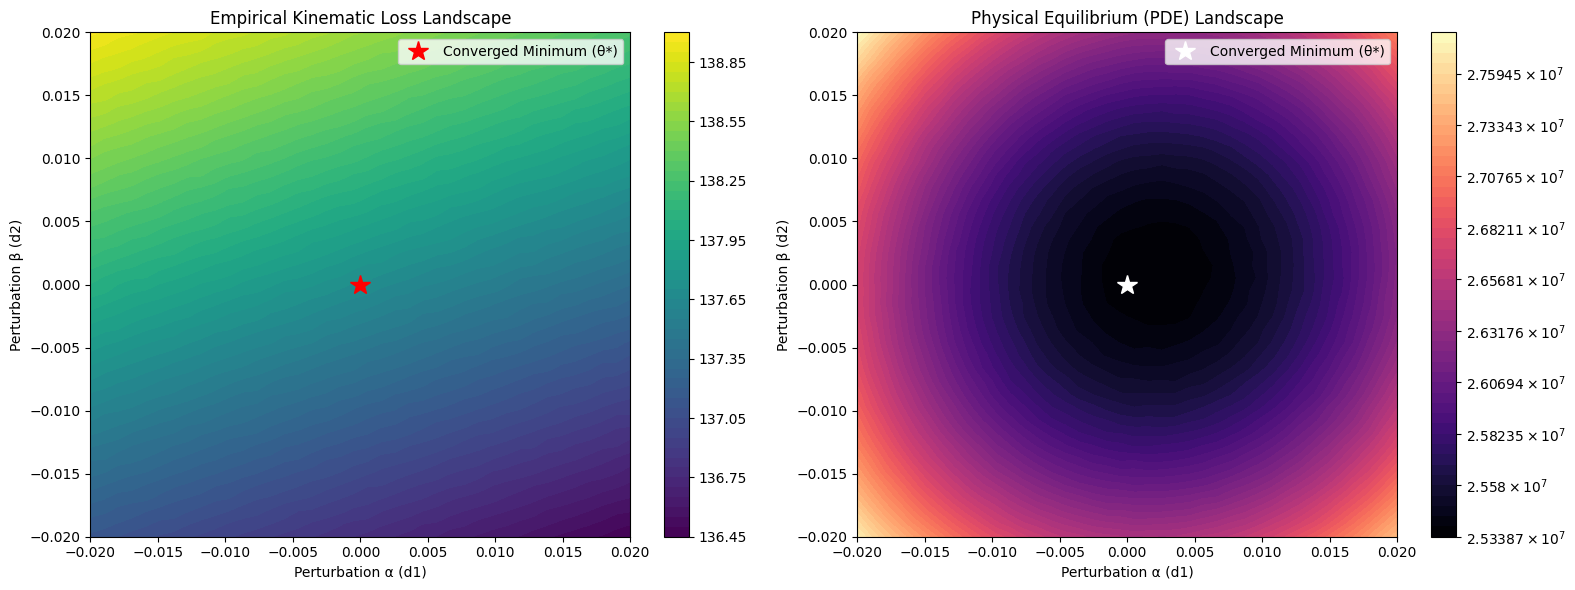

In [40]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import copy
from matplotlib.colors import LogNorm

# Ensure these match your training script configurations
DIC_FILE = 'DIC_2D_Data.csv'
UTM_FILE = 'Specimen_RawData_1.csv'
CHECKPOINT_FILE = 'Weights_1.pth'

def get_flattened_weights(model):
    """Extracts all model parameters into a single 1D tensor."""
    return torch.cat([p.data.view(-1) for p in model.parameters()])

def set_flattened_weights(model, flattened_weights):
    """Injects a 1D tensor back into the model's parameter structure."""
    offset = 0
    for p in model.parameters():
        numel = p.numel()
        p.data.copy_(flattened_weights[offset : offset + numel].view_as(p.data))
        offset += numel

def generate_random_directions(weights):
    """Generates two normalized, orthogonal random direction vectors."""
    d1 = torch.randn_like(weights)
    d2 = torch.randn_like(weights)
    
    # Filter Normalization (Li et al., 2018) for scale-invariance
    d1 = d1 * (weights.norm() / (d1.norm() + 1e-10))
    
    # Orthogonalize d2 with respect to d1
    d2 = d2 - (torch.dot(d2, d1) / (torch.dot(d1, d1) + 1e-10)) * d1
    d2 = d2 * (weights.norm() / (d2.norm() + 1e-10))
    
    return d1, d2

def execute_landscape_scan(model_architecture, data_tensors, resolution=50, limit=1.0):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing Topology Scan on Device: {device.type.upper()}")

    # 1. Load Converged State
    checkpoint = torch.load(CHECKPOINT_FILE, map_location=device)
    raw_state_dict = checkpoint['model_state_dict']
    clean_state_dict = {k.replace('surrogate.', ''): v for k, v in raw_state_dict.items()}
    
    base_model = model_architecture().to(device)
    base_model.load_state_dict(clean_state_dict, strict=False)
    base_model.eval()
    norm = Normalizer()
    norm.mean = checkpoint['normalizer_mean']
    norm.std = checkpoint['normalizer_std']

    # 2. Establish Origin and Perturbation Vectors
    theta_star = get_flattened_weights(base_model)
    d1, d2 = generate_random_directions(theta_star)

    # 3. Define Grid Constraints
    alpha = np.linspace(-limit, limit, resolution)
    beta = np.linspace(-limit, limit, resolution)
    A, B = np.meshgrid(alpha, beta)
    
    loss_data_grid = np.zeros((resolution, resolution))
    loss_pde_grid = np.zeros((resolution, resolution))

    x_b, y_b, t_b, u_b, v_b, p_b, p_dot_b, p_ddot_b, b_mask, t_mask = [
        t.to(device) for t in data_tensors
    ]
    
    x_b.requires_grad_(True)
    y_b.requires_grad_(True)
    t_b.requires_grad_(True)

    print(f"Scanning {resolution}x{resolution} coordinate matrix...")
    
    # 4. Topology Evaluation Loop
    for i in range(resolution):
        for j in range(resolution):
            # Calculate perturbed coordinate: θ_new = θ* + α*d1 + β*d2
            perturbation = (A[i, j] * d1) + (B[i, j] * d2)
            theta_new = theta_star + perturbation
            
            # Inject perturbed weights
            set_flattened_weights(base_model, theta_new)
            
            # Forward Pass & Residual Computation
            l_data, l_pde, _, _, _ = compute_raw_residuals(
                base_model, x_b, y_b, t_b, u_b, v_b, p_b, p_dot_b, p_ddot_b, b_mask, t_mask, norm
            )
            
            loss_data_grid[i, j] = l_data.item()
            loss_pde_grid[i, j] = l_pde.item()
            
        if i % 10 == 0:
            print(f"Matrix Rows Evaluated: {i}/{resolution}")

    # 5. Visualization Generation
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Data Loss Contour (Linear Scale)
    c1 = axes[0].contourf(A, B, loss_data_grid, levels=50, cmap='viridis')
    axes[0].plot(0, 0, 'r*', markersize=15, label='Converged Minimum (θ*)')
    axes[0].set_title('Empirical Kinematic Loss Landscape')
    axes[0].set_xlabel('Perturbation α (d1)')
    axes[0].set_ylabel('Perturbation β (d2)')
    axes[0].legend()
    fig.colorbar(c1, ax=axes[0])
    
    # PDE Loss Contour (Logarithmic Scale to handle explosive gradients)
    c2 = axes[1].contourf(A, B, loss_pde_grid, levels=np.logspace(np.log10(loss_pde_grid.min()), np.log10(loss_pde_grid.max()), 50), cmap='magma', norm=LogNorm())
    axes[1].plot(0, 0, 'w*', markersize=15, label='Converged Minimum (θ*)')
    axes[1].set_title('Physical Equilibrium (PDE) Landscape')
    axes[1].set_xlabel('Perturbation α (d1)')
    axes[1].set_ylabel('Perturbation β (d2)')
    axes[1].legend()
    fig.colorbar(c2, ax=axes[1])
    
    plt.tight_layout()
    plt.savefig('Loss_Landscape_Topology.png', dpi=300)
    plt.show()

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 1. Load the checkpoint normalizer first
    checkpoint = torch.load(CHECKPOINT_FILE, map_location=device)
    saved_norm = Normalizer()
    saved_norm.mean = checkpoint['normalizer_mean']
    saved_norm.std = checkpoint['normalizer_std']

    # 2. Process data using the strict saved normalizer
    # Ensure you are calling the _eval version of the function if you created it
    all_outputs = process_synchronized_tensors(DIC_FILE, UTM_FILE, saved_norm, subsample_ratio=0.01)
    
    # 3. CRITICAL FIX: Slice the tuple to extract ONLY the first 10 tensor objects.
    # This strips the Normalizer object off the end before passing to the scanner.
    data_tensors = all_outputs[:10] 
    
    # 4. Execute scan with the restricted radius
    execute_landscape_scan(OptimizedBifurcatedPINN, data_tensors, resolution=40, limit=0.02)

# D

In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter
import os

# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------
DIC_FILE = '_DIC_Data_Grid_1.csv'
UTM_FILE = 'Specimen_RawData_1.csv'

CROSS_SECTIONAL_AREA = 20.0 * 4.0  # mm^2
DIC_FRAME_RATE = 10.0

EPOCHS = 2000
LR = 1e-3

LAMBDA_DATA = 1.0
LAMBDA_PHYSICS = 1.0
LAMBDA_SMOOTH = 1e-2

# ---------------------------------------------------------
# Data Processing
# ---------------------------------------------------------
def process_data(dic_path, utm_path):
    print("Loading & Synchronizing Data...")

    utm_df = pd.read_csv(utm_path, skiprows=[1])
    utm_df = utm_df.apply(pd.to_numeric, errors='coerce').dropna()

    utm_time = utm_df['Time'].values
    utm_load = utm_df['Load'].values

    filtered_load = savgol_filter(utm_load, 51, 3)

    dic_df = pd.read_csv(dic_path)
    dic_df['time'] = dic_df['img_no'] / DIC_FRAME_RATE

    dic_time = dic_df['time'].values
    sync_load = np.interp(dic_time, utm_time, filtered_load)

    t = torch.tensor(dic_time, dtype=torch.float32).view(-1, 1).requires_grad_(True)
    u = torch.tensor(dic_df['u_AVG'].values, dtype=torch.float32).view(-1, 1)
    P = torch.tensor(sync_load, dtype=torch.float32).view(-1, 1)

    print(f"Data points: {t.shape[0]}")
    return t, u, P

# ---------------------------------------------------------
# 1D PINN Model
# ---------------------------------------------------------
class PINN1D(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 2)
        )

    def forward(self, t):
        out = self.net(t)

        u = out[:, 0:1]
        E = torch.nn.functional.softplus(out[:, 1:2]) + 1.0

        return u, E

# ---------------------------------------------------------
# Loss Function (1D Physics)
# ---------------------------------------------------------
def compute_loss(model, t, u_emp, P_emp):

    u_pred, E_pred = model(t)

    # Data loss
    loss_data = torch.mean((u_pred - u_emp)**2)

    # Strain (time derivative proxy)
    u_t = torch.autograd.grad(u_pred, t, torch.ones_like(u_pred), create_graph=True)[0]

    # Stress = E * strain
    sigma = E_pred * u_t

    # Force
    force = sigma * CROSS_SECTIONAL_AREA

    # Physics loss (force matching)
    loss_physics = torch.mean((force - P_emp)**2)

    # Smoothness on E(t)
    E_t = torch.autograd.grad(E_pred, t, torch.ones_like(E_pred), create_graph=True)[0]
    loss_smooth = torch.mean(E_t**2)

    total_loss = (
        LAMBDA_DATA * loss_data +
        LAMBDA_PHYSICS * loss_physics +
        LAMBDA_SMOOTH * loss_smooth
    )

    return total_loss, loss_data, loss_physics, loss_smooth

# ---------------------------------------------------------
# Training
# ---------------------------------------------------------
if __name__ == "__main__":

    if os.path.exists(DIC_FILE) and os.path.exists(UTM_FILE):

        t, u_exp, P_exp = process_data(DIC_FILE, UTM_FILE)

        model = PINN1D()
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)

        print("Training 1D PINN...")

        for epoch in range(EPOCHS):
            optimizer.zero_grad()

            loss, l_data, l_phys, l_smooth = compute_loss(model, t, u_exp, P_exp)

            loss.backward()
            optimizer.step()

            if epoch % 100 == 0:
                print(f"Epoch {epoch} | Total: {loss.item():.4e} | "
                      f"Data: {l_data.item():.4e} | "
                      f"Physics: {l_phys.item():.4e} | "
                      f"Smooth: {l_smooth.item():.4e}")

        torch.save(model.state_dict(), "PINN_1D_weights.pth")
        print("Training complete.")

    else:
        print("Missing input files.")

Loading & Synchronizing Data...
Data points: 2342
Training 1D PINN...
Epoch 0 | Total: 2.3781e+06 | Data: 1.9253e+00 | Physics: 2.3781e+06 | Smooth: 3.1204e-06
Epoch 100 | Total: 2.3162e+06 | Data: 9.2904e+00 | Physics: 2.3162e+06 | Smooth: 1.1042e-01
Epoch 200 | Total: 1.8630e+06 | Data: 1.0025e+02 | Physics: 1.8629e+06 | Smooth: 4.3369e-01
Epoch 300 | Total: 1.1953e+06 | Data: 2.5648e+02 | Physics: 1.1951e+06 | Smooth: 8.8277e-01
Epoch 400 | Total: 6.6698e+05 | Data: 4.0373e+02 | Physics: 6.6658e+05 | Smooth: 6.5853e-01
Epoch 500 | Total: 3.2245e+05 | Data: 5.3718e+02 | Physics: 3.2191e+05 | Smooth: 4.8305e-01
Epoch 600 | Total: 1.2404e+05 | Data: 6.5853e+02 | Physics: 1.2338e+05 | Smooth: 1.4588e-01
Epoch 700 | Total: 3.9012e+04 | Data: 7.5973e+02 | Physics: 3.8252e+04 | Smooth: 1.6480e-01
Epoch 800 | Total: 1.1718e+04 | Data: 8.2549e+02 | Physics: 1.0892e+04 | Smooth: 1.7767e-01
Epoch 900 | Total: 4.1140e+03 | Data: 8.5868e+02 | Physics: 3.2553e+03 | Smooth: 1.7199e-01
Epoch 1000 |

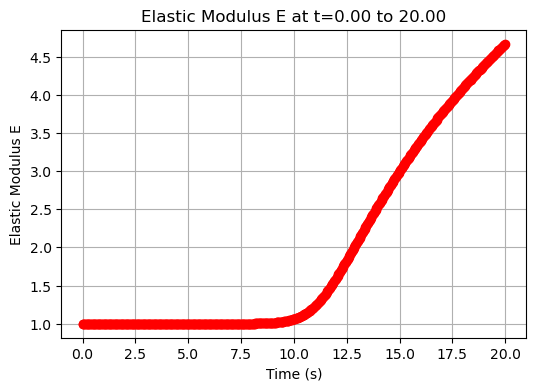

Final Elastic Modulus E at t=20.00: 4.6676 is the final value which is equal to : 4.6676 GPa


In [11]:
def generate_spatial_tensor_maps(model_architecture, weights_file, x_limits, y_limits, grid_resolution=500):
    # This one is for the 1D model, so we will just plot E(t) over the time range
    surrogate_model = model_architecture()
    surrogate_model.load_state_dict(torch.load(weights_file))
    surrogate_model.eval()
    query_time = np.linspace(x_limits[0], x_limits[1], grid_resolution)
    t_tensor = torch.tensor(query_time, dtype=torch.float32).view(-1, 1)
    with torch.no_grad():
        _, E_tensor = surrogate_model(t_tensor)
    E_values = E_tensor.numpy().flatten()
    plt.figure(figsize=(6, 4))
    plt.plot(query_time, E_values, 'ro')
    plt.title(f'Elastic Modulus E at t={query_time[0]:.2f} to {query_time[-1]:.2f}')
    plt.xlabel('Time (s)')
    plt.ylabel('Elastic Modulus E')
    plt.grid()
    plt.savefig(f'Elastic_Modulus_t{query_time[0]:.2f}_to_{query_time[-1]:.2f}.png', dpi=300)
    plt.show()
    # Final E, G value, the final parameters
    print(f"Final Elastic Modulus E at t={query_time[-1]:.2f}: {E_values[-1]:.4f} is the final value which is equal to : {E_values[-1]:.4f} GPa")

generate_spatial_tensor_maps(PINN1D, "PINN_1D_weights.pth", x_limits=(0, 20), y_limits=(0, 4))